# 06 – Finale Evaluation: Scratch vs. Self-Supervised Learning

In diesem Notebook werden die bereits trainierten Modelle auf dem bisher
unangetasteten Test-Split final evaluiert.

Verglichen werden Training from Scratch und Self-Supervised Pretraining mit anschließendem Fine-Tuning jeweils mit 100%, 50%, 25% und 10% der Trainingslabels.

Für jede Konfiguration werden fünf Seeds ausgewertet.

Hier wird der Test-Split für die finale Evaluation verwendet.

Die wichtigste Vergleichsmetrik ist die ROC-AUC.
Zusätzlich werden Accuracy, Precision, Recall, F1 und Average Precision betrachtet.

#### Bibliotheken und Grundeinstellungen

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score)

EXPERIMENT_SEEDS = [7, 21, 42, 84, 123]
LABEL_PERCENTAGES = [100, 50, 25, 10]

BATCH_SIZE = 32
THRESHOLD = 0.5

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Seeds:", EXPERIMENT_SEEDS)
print("Labelanteile:", LABEL_PERCENTAGES)

Device: cpu
Seeds: [7, 21, 42, 84, 123]
Labelanteile: [100, 50, 25, 10]


#### Projekt- und Ergebnispfade

In [2]:
cwd = Path.cwd()

if cwd.name.lower() == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "spoc120_dataset"
)

SUPERVISED_DIR = (
    PROJECT_ROOT
    / "results"
    / "supervised"
)

SSL_DIR = (
    PROJECT_ROOT
    / "results"
    / "ssl"
    / "finetuning"
)

FINAL_EVALUATION_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
)

FINAL_EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VIEWS_FILE = DATA_DIR / "spoc120_views.npz"
METADATA_FILE = DATA_DIR / "spoc120_metadata.csv"

print("Projekt:", PROJECT_ROOT)
print("Daten:", DATA_DIR)
print("Scratch:", SUPERVISED_DIR)
print("SSL:", SSL_DIR)
print("Finale Evaluation:", FINAL_EVALUATION_DIR)

Projekt: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets
Daten: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\processed\spoc120_dataset
Scratch: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\results\supervised
SSL: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\results\ssl\finetuning
Finale Evaluation: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\results\final_evaluation


#### Finalen Datensatz laden

In [3]:
with np.load(
    VIEWS_FILE,
    allow_pickle=False
) as data:
    X_global = data["X_global"]
    X_local = data["X_local"]
    y = data["y"]

metadata = pd.read_csv(
    METADATA_FILE
)

print("X_global:", X_global.shape, X_global.dtype)
print("X_local:", X_local.shape, X_local.dtype)
print("y:", y.shape, y.dtype)
print("Metadaten:", metadata.shape)

X_global: (2282, 201) float32
X_local: (2282, 61) float32
y: (2282,) int64
Metadaten: (2282, 31)


#### Modellinputs vorbereiten

In [4]:
FLUX_CLIP_RELATIVE = 0.02
FLUX_TO_PPT = 1000.0

def prepare_model_views(values):
    return (
        np.clip(
            values,
            -FLUX_CLIP_RELATIVE,
            FLUX_CLIP_RELATIVE
        )
        * FLUX_TO_PPT
    ).astype(
        np.float32,
        copy=False
    )

X_global_prepared = prepare_model_views(
    X_global
)

X_local_prepared = prepare_model_views(
    X_local
)

print(
    "Global:",
    X_global_prepared.min(),
    "bis",
    X_global_prepared.max()
)

print(
    "Local:",
    X_local_prepared.min(),
    "bis",
    X_local_prepared.max()
)

Global: -20.0 bis 20.0
Local: -20.0 bis 20.0


#### Test-Split auswählen

In [5]:
test_mask = metadata["split"] == "test"

X_global_test = X_global_prepared[test_mask]
X_local_test = X_local_prepared[test_mask]
y_test = y[test_mask]

unique, counts = np.unique(
    y_test,
    return_counts=True
)

class_counts = {
    int(label): int(count)
    for label, count in zip(unique, counts)
}

print("Test-Samples:", len(y_test))
print("Klassen:", class_counts)

Test-Samples: 344
Klassen: {0: 157, 1: 187}


#### Modellarchitektur

In [6]:
POOL_OUTPUT_SIZE = 8
ENCODED_FEATURES = 512

class LightCurveEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.AdaptiveAvgPool1d(POOL_OUTPUT_SIZE)
        )

    def forward(self, x):
        x = self.features(x)
        return torch.flatten(x, start_dim=1)


class AstroNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.global_encoder = LightCurveEncoder()
        self.local_encoder = LightCurveEncoder()

        self.classifier = nn.Sequential(
            nn.Linear(
                2 * ENCODED_FEATURES,
                128
            ),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, global_view, local_view):
        global_features = self.global_encoder(
            global_view
        )

        local_features = self.local_encoder(
            local_view
        )

        features = torch.cat(
            [global_features, local_features],
            dim=1
        )

        return self.classifier(features).squeeze(1)

#### Test-Dataset definieren

In [7]:
class LightCurveDataset(Dataset):
    def __init__(self, global_views, local_views, labels):
        self.global_views = torch.from_numpy(global_views)
        self.local_views = torch.from_numpy(local_views)
        self.labels = torch.from_numpy(labels).float()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.global_views[index].unsqueeze(0),
            self.local_views[index].unsqueeze(0),
            self.labels[index]
        )

#### Test-Dataloader erstellen

In [8]:
test_dataset = LightCurveDataset(
    X_global_test,
    X_local_test,
    y_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test-Samples:", len(test_dataset))
print("Batches:", len(test_loader))

Test-Samples: 344
Batches: 11


#### 20 Scratch und 20 SSL Modelle prüfen

In [9]:
scratch_model_files = [
    SUPERVISED_DIR
    / f"baseline_{percentage}pct_seed_{seed}.pt"
    for percentage in LABEL_PERCENTAGES
    for seed in EXPERIMENT_SEEDS
]

ssl_model_files = [
    SSL_DIR
    / f"ssl_finetuned_{percentage}_seed_{seed}.pt"
    for percentage in LABEL_PERCENTAGES
    for seed in EXPERIMENT_SEEDS
]

missing_scratch = [
    path.name
    for path in scratch_model_files
    if not path.exists()
]

missing_ssl = [
    path.name
    for path in ssl_model_files
    if not path.exists()
]

print("Scratch-Modelle:", len(scratch_model_files))
print("SSL-Modelle:", len(ssl_model_files))
print("Fehlende Scratch-Modelle:", missing_scratch)
print("Fehlende SSL-Modelle:", missing_ssl)

Scratch-Modelle: 20
SSL-Modelle: 20
Fehlende Scratch-Modelle: []
Fehlende SSL-Modelle: []


#### Evaluationfunktion definieren

In [10]:
def evaluate_model(model_path):
    model = AstroNetClassifier().to(device)

    state_dict = torch.load(
        model_path,
        map_location=device,
        weights_only=True
    )

    model.load_state_dict(state_dict)
    model.eval()

    y_true = []
    y_prob = []

    with torch.no_grad():
        for global_view, local_view, labels in test_loader:
            global_view = global_view.to(device)
            local_view = local_view.to(device)

            logits = model(
                global_view,
                local_view
            )

            probabilities = torch.sigmoid(logits)

            y_true.extend(
                labels.numpy()
            )

            y_prob.extend(
                probabilities.cpu().numpy()
            )

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= THRESHOLD).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(
            y_true,
            y_prob
        )
    }

#### Finale Testevaluation

In [11]:
test_results = []

for method, model_dir in [
    ("Scratch", SUPERVISED_DIR),
    ("SSL", SSL_DIR)
]:
    for percentage in LABEL_PERCENTAGES:
        for seed in EXPERIMENT_SEEDS:

            if method == "Scratch":
                model_path = (
                    model_dir
                    / f"baseline_{percentage}pct_seed_{seed}.pt"
                )
            else:
                model_path = (
                    model_dir
                    / f"ssl_finetuned_{percentage}_seed_{seed}.pt"
                )

            metrics = evaluate_model(
                model_path
            )

            test_results.append({
                "method": method,
                "label_percentage": percentage,
                "seed": seed,
                **metrics
            })

test_results_df = pd.DataFrame(
    test_results
)

print("Evaluierte Modelle:", len(test_results_df))

test_results_df.head()

Evaluierte Modelle: 40


,method,label_percentage,seed,accuracy,precision,recall,f1,roc_auc,average_precision
0,Scratch,100,7,0.729651,0.764045,0.727273,0.745205,0.790047,0.824121
1,Scratch,100,21,0.709302,0.808511,0.609626,0.695122,0.791580,0.838225
2,Scratch,100,42,0.723837,0.734694,0.770053,0.751958,0.791921,0.819767
3,Scratch,100,84,0.715116,0.787097,0.652406,0.713450,0.805068,0.821070
4,Scratch,100,123,0.688953,0.785714,0.588235,0.672783,0.782145,0.820406


#### Zusammenfassung der Ergebnisse über fünf Seeds

In [12]:
metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision"
]

test_summary = (
    test_results_df
    .groupby(
        ["method", "label_percentage"]
    )[metric_columns]
    .agg(["mean", "std"])
    .round(4)
)

test_summary

accuracy         precision          recall          \
                             mean     std      mean     std    mean     std   
method  label_percentage                                                      
SSL     10                 0.6378  0.0146    0.7307  0.0267  0.5305  0.0337   
        25                 0.6826  0.0337    0.7693  0.0244  0.5979  0.1013   
        50                 0.7390  0.0198    0.7946  0.0136  0.7027  0.0663   
        100                0.7262  0.0161    0.7810  0.0350  0.6952  0.0641   
Scratch 10                 0.6087  0.0157    0.6665  0.0055  0.5604  0.0512   
        25                 0.6628  0.0226    0.7214  0.0200  0.6203  0.0647   
        50                 0.7128  0.0305    0.7678  0.0224  0.6791  0.0924   
        100                0.7134  0.0157    0.7760  0.0279  0.6695  0.0773   

                              f1         roc_auc         average_precision  \
                            mean     std    mean     std              mean   
method  label_percentage                                                     
SSL     10                0.6139  0.0206  0.7049  0.0129            0.7151   
        25                0.6679  0.0620  0.7582  0.0147            0.7737   
        50                0.7440  0.0328  0.8007  0.0137            0.8169   
        100               0.7330  0.0253  0.8009  0.0022            0.8354   
Scratch 10                0.6079  0.0318  0.6706  0.0112            0.6748   
        25                0.6653  0.0364  0.7212  0.0130            0.7286   
        50                0.7172  0.0501  0.7751  0.0174            0.8010   
        100               0.7157  0.0334  0.7922  0.0082            0.8247   

                                  
                             std  
method  label_percentage          
SSL     10                0.0156  
        25                0.0159  
        50                0.0116  
        100               0.0121  
Scratch 10                0.0086  
        25                0.0059  
        50                0.0186  
        100               0.0077

#### ROC-AUC-Vergleich

In [13]:
roc_comparison = (
    test_results_df
    .groupby(
        ["method", "label_percentage"]
    )["roc_auc"]
    .agg(["mean", "std"])
    .reset_index()
)

roc_comparison = roc_comparison.pivot(
    index="label_percentage",
    columns="method",
    values=["mean", "std"]
)

comparison_df = pd.DataFrame({
    "Scratch ROC-AUC": roc_comparison["mean"]["Scratch"],
    "Scratch Std": roc_comparison["std"]["Scratch"],
    "SSL ROC-AUC": roc_comparison["mean"]["SSL"],
    "SSL Std": roc_comparison["std"]["SSL"]
})

comparison_df["Delta"] = (
    comparison_df["SSL ROC-AUC"]
    - comparison_df["Scratch ROC-AUC"]
)

comparison_df = (
    comparison_df
    .loc[[100, 50, 25, 10]]
    .round(4)
)

comparison_df

,Scratch ROC-AUC,Scratch Std,SSL ROC-AUC,SSL Std,Delta
label_percentage,,,,,
100,0.7922,0.0082,0.8009,0.0022,0.0088
50,0.7751,0.0174,0.8007,0.0137,0.0256
25,0.7212,0.0130,0.7582,0.0147,0.0370
10,0.6706,0.0112,0.7049,0.0129,0.0343


#### ROC-AUC-Differenzen

In [14]:
scratch_auc = (
    test_results_df[
        test_results_df["method"] == "Scratch"
    ]
    .pivot(
        index="seed",
        columns="label_percentage",
        values="roc_auc"
    )
)

ssl_auc = (
    test_results_df[
        test_results_df["method"] == "SSL"
    ]
    .pivot(
        index="seed",
        columns="label_percentage",
        values="roc_auc"
    )
)

paired_delta = (
    ssl_auc - scratch_auc
)[[100, 50, 25, 10]]

paired_delta.columns = [
    "100 %",
    "50 %",
    "25 %",
    "10 %"
]

paired_delta.round(4)

,100 %,50 %,25 %,10 %
seed,,,,
7,0.0071,-0.0080,0.0324,0.0586
21,0.0095,0.0625,0.0278,0.0434
42,0.0105,0.0085,0.0427,0.0180
84,-0.0029,0.0123,0.0636,0.0162
123,0.0196,0.0527,0.0186,0.0352


#### Scratch vs. SSL

Dargestellt sind Mittelwert und Standardabweichung über fünf Seeds.

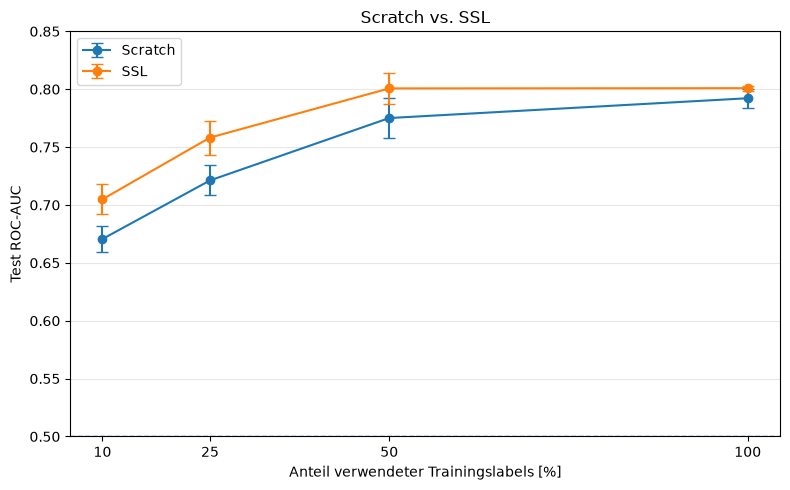

In [15]:
label_order = [10, 25, 50, 100]

plot_data = comparison_df.loc[
    label_order
]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.errorbar(
    label_order,
    plot_data["Scratch ROC-AUC"],
    yerr=plot_data["Scratch Std"],
    marker="o",
    capsize=4,
    label="Scratch"
)

ax.errorbar(
    label_order,
    plot_data["SSL ROC-AUC"],
    yerr=plot_data["SSL Std"],
    marker="o",
    capsize=4,
    label="SSL"
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("Anteil verwendeter Trainingslabels [%]")
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Scratch vs. SSL")

ax.set_xticks(label_order)
ax.set_ylim(0.5, 0.85)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FINAL_EVALUATION_DIR
    / "roc_auc_scratch_vs_ssl.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Mittlerer ROC-AUC-Vorteil durch SSL visualisieren

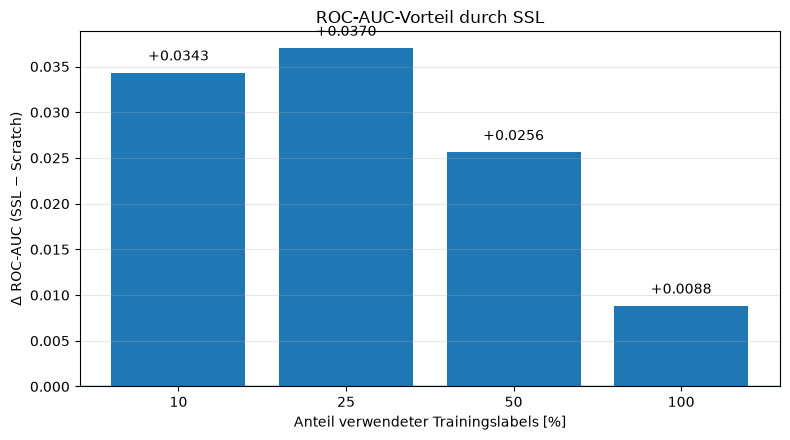

In [16]:
delta_plot = comparison_df.loc[
    [10, 25, 50, 100],
    "Delta"
]

fig, ax = plt.subplots(
    figsize=(8, 4.5)
)

bars = ax.bar(
    delta_plot.index.astype(str),
    delta_plot.values
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "Anteil verwendeter Trainingslabels [%]"
)

ax.set_ylabel(
    "Δ ROC-AUC (SSL − Scratch)"
)

ax.set_title(
    "ROC-AUC-Vorteil durch SSL"
)

for bar, value in zip(
    bars,
    delta_plot.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.001,
        f"{value:+.4f}",
        ha="center",
        va="bottom"
    )

ax.grid(
    axis="y",
    alpha=0.3
)

fig.tight_layout()

fig.savefig(
    FINAL_EVALUATION_DIR
    / "roc_auc_delta_ssl_vs_scratch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Finale Metrikenübersicht

In [17]:
final_table = (
    test_results_df
    .groupby(
        ["method", "label_percentage"]
    )[
        [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "average_precision"
        ]
    ]
    .mean()
    .round(4)
)

final_table

accuracy  precision  recall      f1  roc_auc  \
method  label_percentage                                                 
SSL     10                  0.6378     0.7307  0.5305  0.6139   0.7049   
        25                  0.6826     0.7693  0.5979  0.6679   0.7582   
        50                  0.7390     0.7946  0.7027  0.7440   0.8007   
        100                 0.7262     0.7810  0.6952  0.7330   0.8009   
Scratch 10                  0.6087     0.6665  0.5604  0.6079   0.6706   
        25                  0.6628     0.7214  0.6203  0.6653   0.7212   
        50                  0.7128     0.7678  0.6791  0.7172   0.7751   
        100                 0.7134     0.7760  0.6695  0.7157   0.7922   

                          average_precision  
method  label_percentage                     
SSL     10                           0.7151  
        25                           0.7737  
        50                           0.8169  
        100                          0.8354  
Scratch 10                           0.6748  
        25                           0.7286  
        50                           0.8010  
        100                          0.8247

#### ROC-AUC-Differenzen über alle Seeds

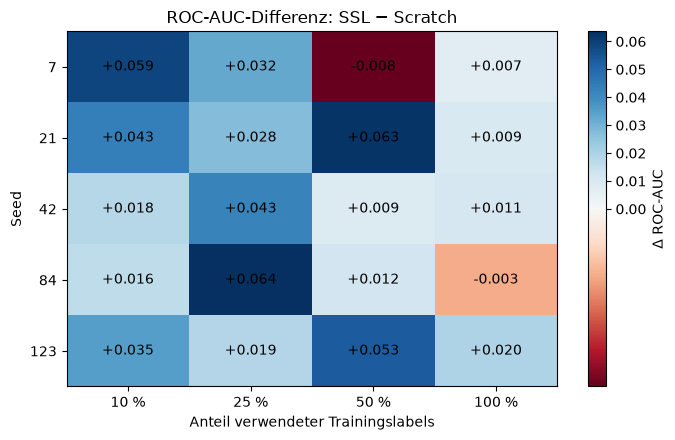

In [18]:

heatmap_data = paired_delta[
    ["10 %", "25 %", "50 %", "100 %"]
]

fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

norm = TwoSlopeNorm(
    vmin=heatmap_data.values.min(),
    vcenter=0,
    vmax=heatmap_data.values.max()
)

image = ax.imshow(
    heatmap_data.values,
    cmap="RdBu",
    norm=norm,
    aspect="auto"
)

ax.set_xticks(
    range(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)

ax.set_yticks(
    range(len(heatmap_data.index)),
    labels=heatmap_data.index
)

ax.set_xlabel("Anteil verwendeter Trainingslabels")
ax.set_ylabel("Seed")
ax.set_title("ROC-AUC-Differenz: SSL − Scratch")

for row in range(heatmap_data.shape[0]):
    for col in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[row, col]

        ax.text(
            col,
            row,
            f"{value:+.3f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    image,
    ax=ax,
    label="Δ ROC-AUC"
)

fig.tight_layout()

fig.savefig(
    FINAL_EVALUATION_DIR
    / "roc_auc_delta_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Unterscheide der Testmetriken

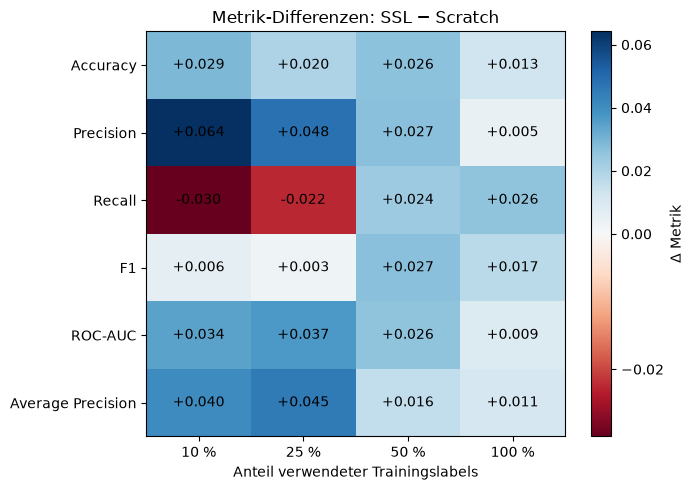

In [19]:
metric_means = (
    test_results_df
    .groupby(
        ["method", "label_percentage"]
    )[metric_columns]
    .mean()
)

metric_delta = (
    metric_means.loc["SSL"]
    - metric_means.loc["Scratch"]
)

metric_delta = (
    metric_delta
    .loc[[10, 25, 50, 100]]
    .T
)

metric_delta.index = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "Average Precision"
]

metric_delta.columns = [
    "10 %",
    "25 %",
    "50 %",
    "100 %"
]

fig, ax = plt.subplots(
    figsize=(7, 5)
)

norm = TwoSlopeNorm(
    vmin=metric_delta.values.min(),
    vcenter=0,
    vmax=metric_delta.values.max()
)

image = ax.imshow(
    metric_delta.values,
    cmap="RdBu",
    norm=norm,
    aspect="auto"
)

ax.set_xticks(
    range(len(metric_delta.columns)),
    labels=metric_delta.columns
)

ax.set_yticks(
    range(len(metric_delta.index)),
    labels=metric_delta.index
)

ax.set_xlabel("Anteil verwendeter Trainingslabels")
ax.set_title("Metrik-Differenzen: SSL − Scratch")

for row in range(metric_delta.shape[0]):
    for col in range(metric_delta.shape[1]):
        value = metric_delta.iloc[row, col]

        ax.text(
            col,
            row,
            f"{value:+.3f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    image,
    ax=ax,
    label="Δ Metrik"
)

fig.tight_layout()

fig.savefig(
    FINAL_EVALUATION_DIR
    / "metric_delta_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Ergebnisse speichern

In [20]:
summary_for_csv = test_summary.copy()

summary_for_csv.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary_for_csv.columns
]

summary_for_csv = summary_for_csv.reset_index()

test_results_df.to_csv(
    FINAL_EVALUATION_DIR / "test_results_per_seed.csv",
    index=False
)

summary_for_csv.to_csv(
    FINAL_EVALUATION_DIR / "test_summary.csv",
    index=False
)

comparison_df.reset_index().to_csv(
    FINAL_EVALUATION_DIR / "scratch_vs_ssl_comparison.csv",
    index=False
)

paired_delta.reset_index().to_csv(
    FINAL_EVALUATION_DIR / "paired_roc_auc_delta.csv",
    index=False
)

final_table.reset_index().to_csv(
    FINAL_EVALUATION_DIR / "final_metrics_table.csv",
    index=False
)

print("Ergebnisse gespeichert:")
print(FINAL_EVALUATION_DIR)

Ergebnisse gespeichert:
c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\results\final_evaluation


### Ergebnis der finalen Evaluation

Die finale Evaluation wurde auf dem bisher unangetasteten Test-Split mit
344 Samples durchgeführt. Für jede Konfiguration wurden fünf Seeds
ausgewertet.

ROC-AUC ist hierbei die primäre Vergleichsmetrik

| Trainingslabels | Scratch ROC-AUC | SSL ROC-AUC | Δ SSL − Scratch |
|---:|---:|---:|---:|
| 100 % | 0.7922 ± 0.0082 | 0.8009 ± 0.0022 | +0.0088 |
| 50 %  | 0.7751 ± 0.0174 | 0.8007 ± 0.0137 | +0.0256 |
| 25 %  | 0.7212 ± 0.0130 | 0.7582 ± 0.0147 | +0.0370 |
| 10 %  | 0.6706 ± 0.0112 | 0.7049 ± 0.0129 | +0.0343 |

Self-Supervised Pretraining erzielt damit bei allen vier untersuchten
Labelanteilen im Mittel eine höhere ROC-AUC als das Training from Scratch.

Der Unterschied ist bei 100 % der Trainingslabels mit +0.0088 relativ klein.
Bei reduzierter Labelmenge fällt der Vorteil stärker aus. Die größten
Verbesserungen zeigen sich bei 25 % (+0.0370) und 10 % (+0.0343) der
Trainingslabels.

Auch die gepaarte Betrachtung der Seeds zeigt dieses Muster.
Bei 10 % und 25 % der Labels erzielt SSL bei allen fünf Seeds eine höhere
ROC-AUC. Bei 50 % und 100 % ist SSL bei jeweils vier von fünf Seeds besser.

Die Ergebnisse sprechen daher dafür, dass das verwendete
Self-Supervised Pretraining insbesondere bei begrenzter Verfügbarkeit
gelabelter Trainingsdaten hilfreich sein kann.